- 라이브러리 임포트

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import koreanize_matplotlib
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import FuncFormatter

- 가상의 상품 정보 데이터 만들기 (Products)
- 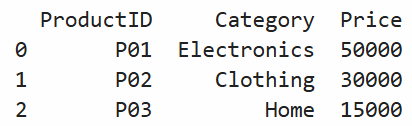

In [8]:
ProductID = ['P01','P02','P03']
Category = ['Electronics', 'Clothing', 'Home']
Price = [50000, 30000, 15000]

df1 = pd.DataFrame({
    'ProductID': ProductID,
    'Category': Category,
    'Price': Price
})

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ProductID  3 non-null      object
 1   Category   3 non-null      object
 2   Price      3 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes


- 100일 치의 가상 주문 내역 데이터 만들기 (Orders)

In [17]:
date = pd.date_range('2023-1-1',periods=100)
rng = np.random.default_rng(0)
productid = rng.choice(['P01','P02','P03'], size=100)
quantity = rng.integers(1,10,100)
productid
quantity

df2 = pd.DataFrame(
    {'Date' : date,
     'ProductID' : productid,
     'Quantity' : quantity
    }
)
df2

,Date,ProductID,Quantity
0,2023-01-01,P03,4
1,2023-01-02,P02,8
2,2023-01-03,P02,3
3,2023-01-04,P01,3
4,2023-01-05,P01,8
...,...,...,...
95,2023-04-06,P02,9
96,2023-04-07,P01,4
97,2023-04-08,P01,9
98,2023-04-09,P02,4


- 상품정보와 주문내역 정보 출력
-  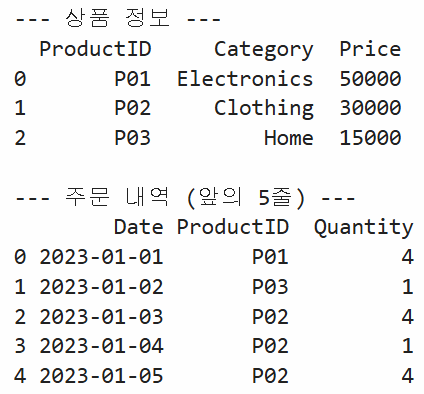

- 상품정보와 주문내역 합치기(merge)
- orders를 기준으로 products 데이터를 가져와서 붙임

In [18]:
df = pd.merge(df2, df1, on='ProductID', how='left')
df

,Date,ProductID,Quantity,Category,Price
0,2023-01-01,P03,4,Home,15000
1,2023-01-02,P02,8,Clothing,30000
2,2023-01-03,P02,3,Clothing,30000
3,2023-01-04,P01,3,Electronics,50000
4,2023-01-05,P01,8,Electronics,50000
...,...,...,...,...,...
95,2023-04-06,P02,9,Clothing,30000
96,2023-04-07,P01,4,Electronics,50000
97,2023-04-08,P01,9,Electronics,50000
98,2023-04-09,P02,4,Clothing,30000


- 매출액(Revenue) 계산하기 (가격 x 수량)

In [19]:
df['Revenue'] = df['Price'] * df['Quantity']
df['Revenue'].head()

0     60000
1    240000
2     90000
3    150000
4    400000
Name: Revenue, dtype: int64

- 월(Month) 정보만 따로 뽑아내기

In [20]:
df['Month'] = pd.to_datetime(df['Date']).dt.month
df['Month']

0     1
1     1
2     1
3     1
4     1
     ..
95    4
96    4
97    4
98    4
99    4
Name: Month, Length: 100, dtype: int32

- 합쳐진 데이터 출력

In [21]:
df.head()

,Date,ProductID,Quantity,Category,Price,Revenue,Month
0,2023-01-01,P03,4,Home,15000,60000,1
1,2023-01-02,P02,8,Clothing,30000,240000,1
2,2023-01-03,P02,3,Clothing,30000,90000,1
3,2023-01-04,P01,3,Electronics,50000,150000,1
4,2023-01-05,P01,8,Electronics,50000,400000,1


- 피벗 테이블 만들기( 행 : 월, 열 : 카테고리, 값 : 매출액, 계산함수 : 합계 )

In [48]:
monthly_sales = pd.pivot_table(
    df,           # 데이터프레임
    values='Revenue',    # 집계할 컬럼
    index='Month',     # 행으로 쓸 컬럼
    columns='Category',   # 열로 쓸 컬럼
    aggfunc='sum', # 집계 함수 (예: mean, sum, len)
)
monthly_sales.isnull().sum()
monthly_sales.fillna(0)

TypeError: unsupported operand type(s) for /: 'str' and 'int'

- 데이터가 비어있는 곳(NaN)은 0으로 채우기

- 피벗테이블 출력

In [25]:
monthly_sales

Category,Clothing,Electronics,Home
Month,,,
1,1860000,2100000,945000
2,1770000,2800000,540000
3,2160000,1500000,1050000
4,390000,1350000,330000


- 시각화
- 누적 막대그래프 그리기
  - monthly_sales.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set1')
  - 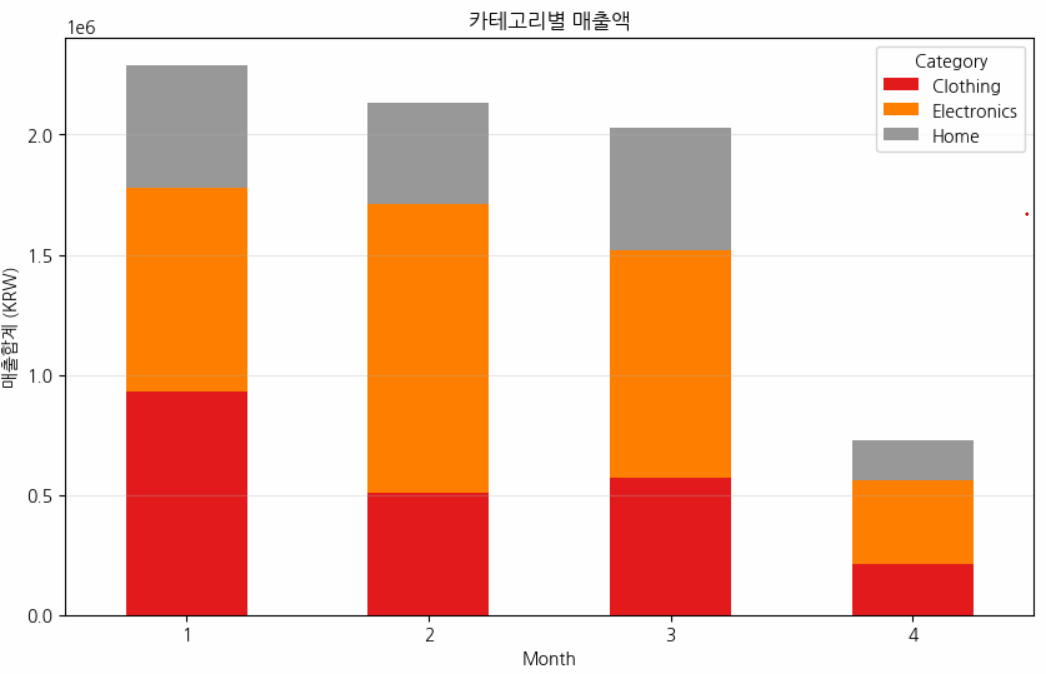

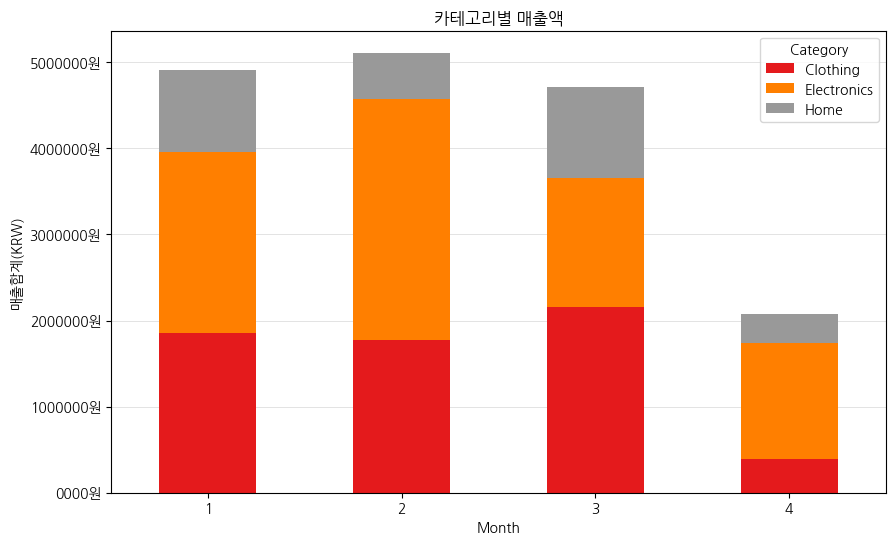

In [66]:
monthly_sales.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set1')
plt.title('카테고리별 매출액')
plt.ylabel('매출합계(KRW)')
plt.grid(True, axis='y',lw=0.5, alpha=0.5)
plt.gca().set_axisbelow(True)
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{int(y/1000)}000원'))
plt.savefig('카테고리별 매출액.png')
plt.show()